# Framingham Heart Study — Classification Assignment

## Introduction / Problem Statement

### Objectives
- Dataset ko analyze karna aur samajhna
- Missing values handle karna
- Required encoding perform karna (agar zarurat ho)
- Feature scaling apply karna
- Imbalanced dataset ko balance karna (SMOTE)
- Multiple classification models train karna aur compare karna
- Accuracy, Precision, Recall, F1-Score, Classification Report, Confusion Matrix nikalna
- Best model select karke hyperparameter tuning se performance improve karna



## Import Libraries

In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

##  Load Dataset

In [8]:
df = pd.read_csv('framingham.csv')

print("Shape:", df.shape)
df.head()

Shape: (4238, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [10]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## Exploratory Data Analysis (EDA)

In [11]:
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("Percentage of rows with at least 1 missing value:",
      round(df.isnull().any(axis=1).mean() * 100, 2), "%")

Missing values per column:

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Total missing values: 645
Percentage of rows with at least 1 missing value: 13.73 %


TenYearCHD
0    3594
1     644
Name: count, dtype: int64

Class Percentage:
TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


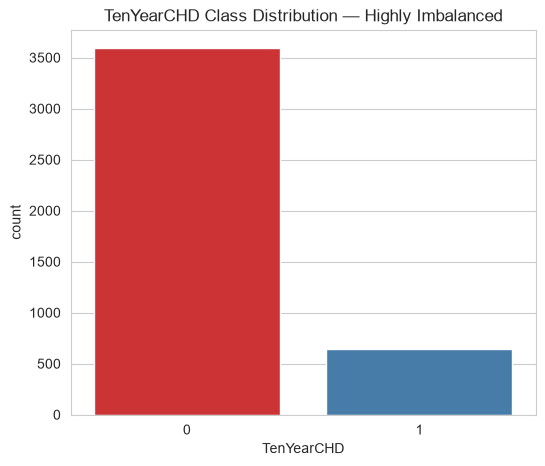

In [12]:
print(df['TenYearCHD'].value_counts())
print("\nClass Percentage:")
print(df['TenYearCHD'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='TenYearCHD', palette='Set1')
plt.title('TenYearCHD Class Distribution — Highly Imbalanced')
plt.show()

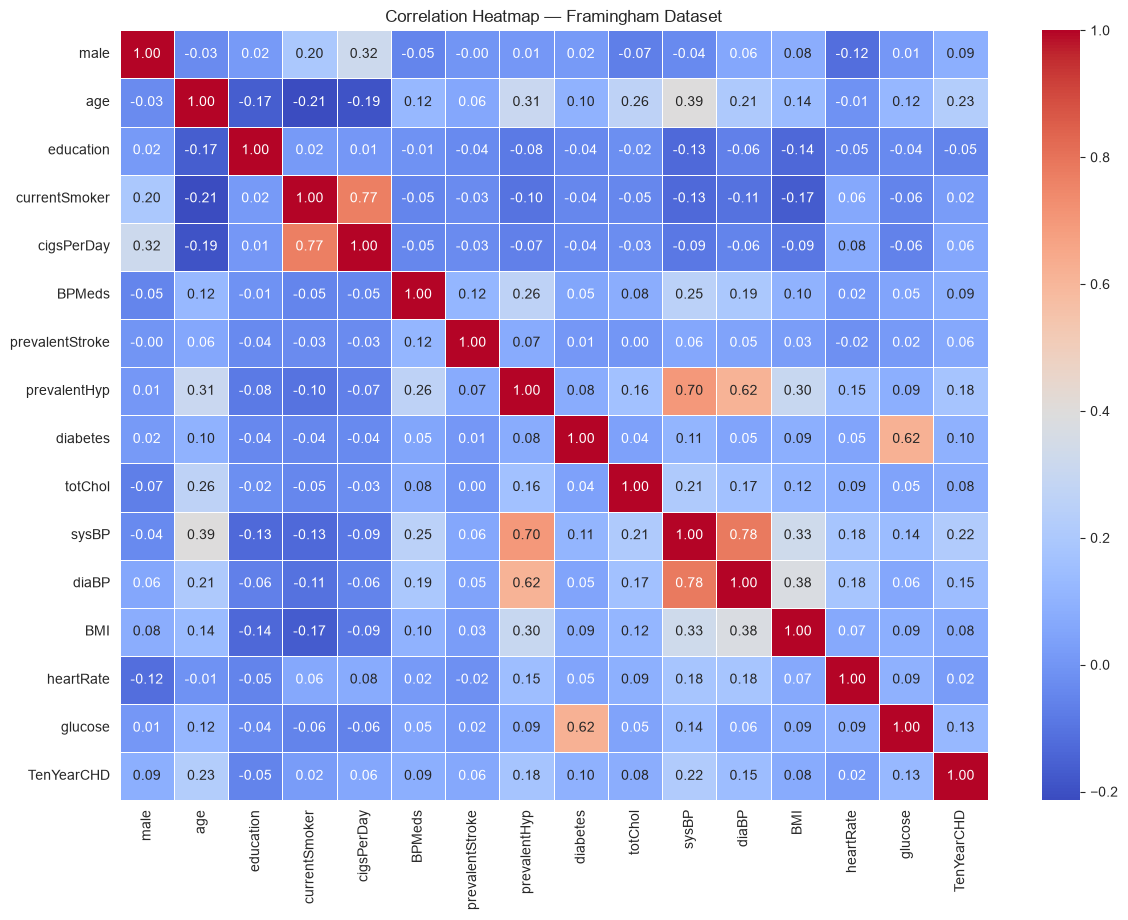

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Framingham Dataset')
plt.show()

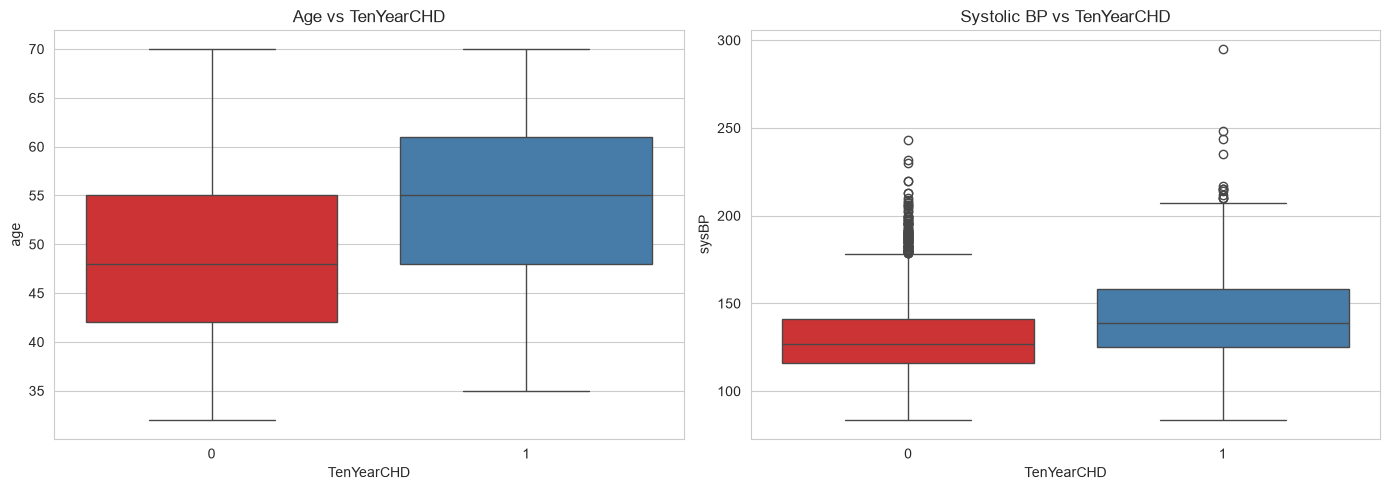

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='TenYearCHD', y='age', ax=axes[0], palette='Set1')
axes[0].set_title('Age vs TenYearCHD')
sns.boxplot(data=df, x='TenYearCHD', y='sysBP', ax=axes[1], palette='Set1')
axes[1].set_title('Systolic BP vs TenYearCHD')
plt.tight_layout()
plt.show()

## Data Preprocessing



In [18]:
print("Before imputation:\n", df.isnull().sum()[df.isnull().sum() > 0])

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nAfter imputation - total missing:", df.isnull().sum().sum())

Before imputation:
 Series([], dtype: int64)

After imputation - total missing: 0


In [19]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4238, 15)
Target shape: (4238,)


## Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining class balance:\n", y_train.value_counts())

Training set: (3390, 15)
Testing set: (848, 15)

Training class balance:
 TenYearCHD
0    2875
1     515
Name: count, dtype: int64


## Feature Scaling

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done")

Feature scaling done


## Handling Class Imbalance (SMOTE)

In [22]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())

Before SMOTE: {0: 2875, 1: 515}
After SMOTE: {0: 2875, 1: 2875}


## Model Building — Multiple Classification Models

In [23]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    trained_models[name] = model

    print(f"{name} trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained
Gradient Boosting trained
SVM trained
KNN trained
Naive Bayes trained


## Model Evaluation & Comparison

In [24]:
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.663915,0.248387,0.596899,0.350797
1,SVM,0.696934,0.239837,0.457364,0.314667
2,Gradient Boosting,0.766509,0.280255,0.341085,0.307692
3,KNN,0.642689,0.211921,0.496124,0.296984
4,Decision Tree,0.725236,0.214286,0.302326,0.250804
5,Naive Bayes,0.773585,0.239669,0.224806,0.232000
6,Random Forest,0.791274,0.239130,0.170543,0.199095


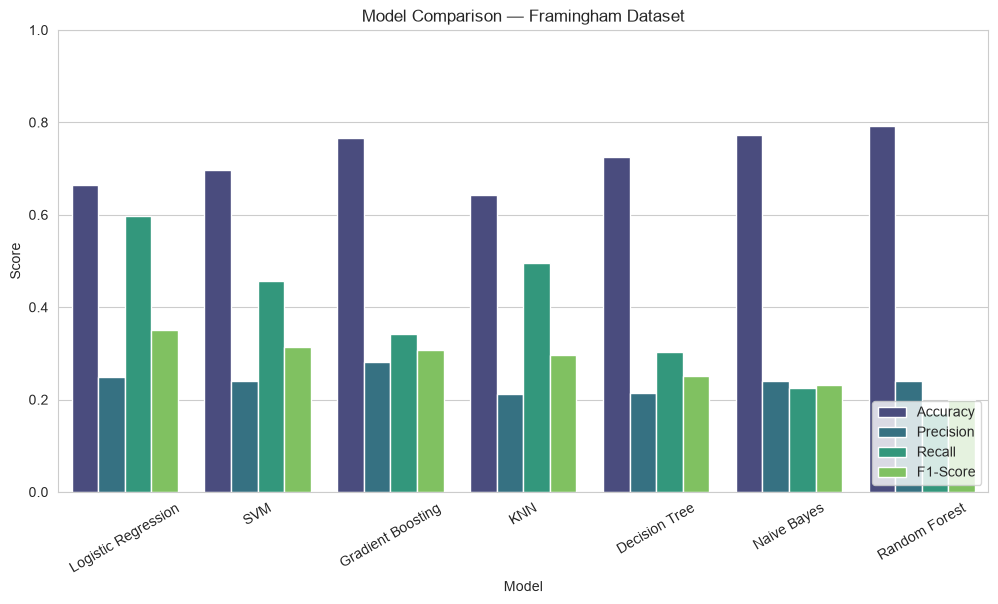

In [25]:
results_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melt, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Model Comparison — Framingham Dataset')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

In [26]:
best_model_name = results_df.iloc[0]['Model']
print(f" Best Performing Model (before tuning): {best_model_name}")
print(results_df.iloc[0])

 Best Performing Model (before tuning): Logistic Regression
Model        Logistic Regression
Accuracy                0.663915
Precision               0.248387
Recall                  0.596899
F1-Score                0.350797
Name: 0, dtype: object


Classification Report — Logistic Regression

              precision    recall  f1-score   support

           0       0.90      0.68      0.77       719
           1       0.25      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.66      0.71       848



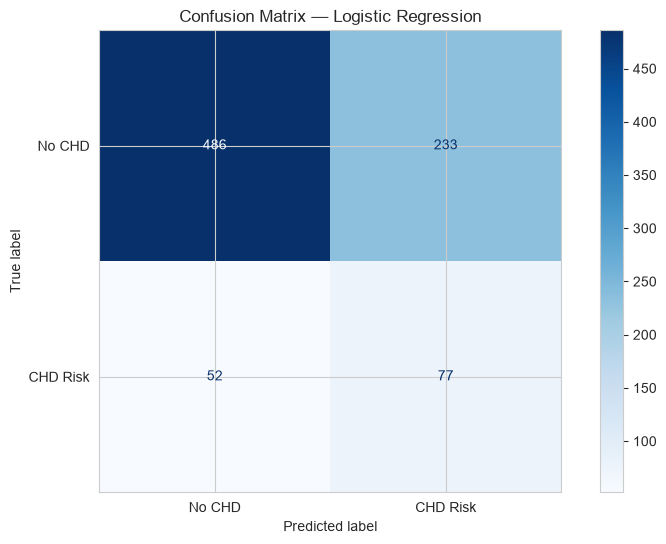

In [27]:
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"Classification Report — {best_model_name}\n")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CHD', 'CHD Risk'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

## Hyperparameter Tuning



In [28]:
def get_param_grid(model_name):
    grids = {
        'Random Forest': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5]
        },
        'Decision Tree': {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        },
        'Logistic Regression': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        },
        'SVM': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        },
        'KNN': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance']
        },
        'Naive Bayes': {
            'var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    }
    return grids[model_name]

if best_model_name == 'Logistic Regression':
    base_model = LogisticRegression(random_state=42, max_iter=1000)
elif best_model_name == 'Random Forest':
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
elif best_model_name == 'Gradient Boosting':
    base_model = GradientBoostingClassifier(random_state=42)
elif best_model_name == 'Decision Tree':
    base_model = DecisionTreeClassifier(random_state=42)
elif best_model_name == 'SVM':
    base_model = SVC(random_state=42, probability=True)
elif best_model_name == 'KNN':
    base_model = KNeighborsClassifier()
else:
    base_model = GaussianNB()

param_grid = get_param_grid(best_model_name)

grid = GridSearchCV(base_model, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train_bal, y_train_bal)

print(f"\n Tuning: {best_model_name}")
print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits

 Tuning: Logistic Regression
Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


Tuned Logistic Regression Performance:
Accuracy  : 0.6580
Precision : 0.2444
Recall    : 0.5969
F1-Score  : 0.3468

Before tuning F1 was: 0.3508 -> After tuning: 0.3468

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.67      0.77       719
           1       0.24      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.57      0.63      0.56       848
weighted avg       0.80      0.66      0.70       848



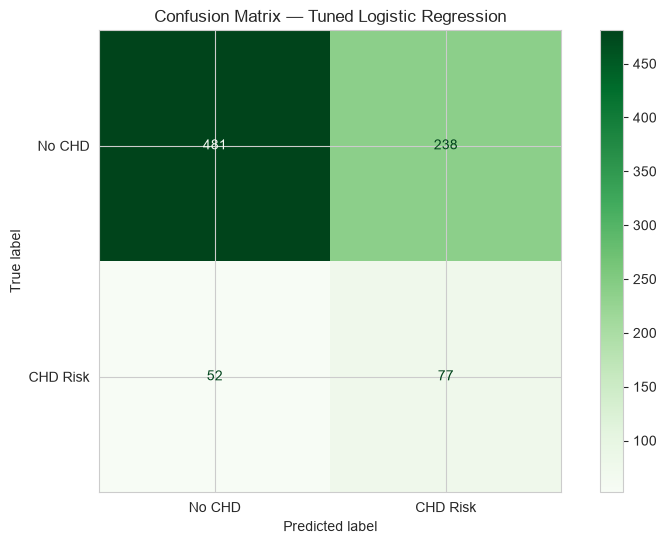

In [29]:
tuned_model = grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)

acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)

print(f"Tuned {best_model_name} Performance:")
print(f"Accuracy  : {acc_t:.4f}")
print(f"Precision : {prec_t:.4f}")
print(f"Recall    : {rec_t:.4f}")
print(f"F1-Score  : {f1_t:.4f}")
print(f"\nBefore tuning F1 was: {results_df.iloc[0]['F1-Score']:.4f} -> After tuning: {f1_t:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))

cm_t = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=['No CHD', 'CHD Risk'])
disp.plot(cmap='Greens')
plt.title(f'Confusion Matrix — Tuned {best_model_name}')
plt.show()

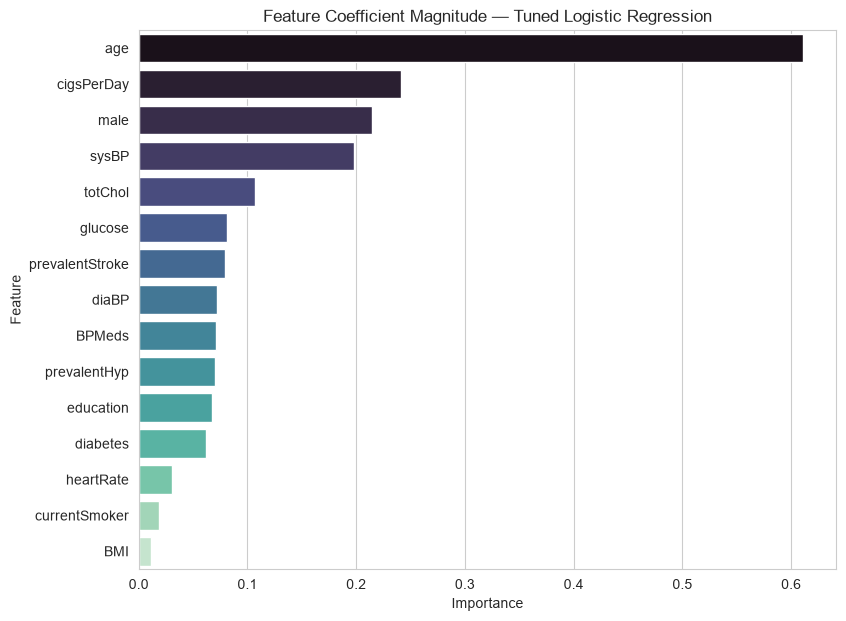

            Feature  Importance
1               age    0.610888
4        cigsPerDay    0.240766
0              male    0.214631
10            sysBP    0.197991
9           totChol    0.106560
14          glucose    0.081316
6   prevalentStroke    0.079170
11            diaBP    0.071639
5            BPMeds    0.071008
7      prevalentHyp    0.070261
2         education    0.067177
8          diabetes    0.062195
13        heartRate    0.030439
3     currentSmoker    0.018273
12              BMI    0.010925


In [30]:
if hasattr(tuned_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature': X.columns,
        'Importance': tuned_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    title = f'Feature Importance — Tuned {best_model_name}'
elif hasattr(tuned_model, 'coef_'):
    fi = pd.DataFrame({
        'Feature': X.columns,
        'Importance': np.abs(tuned_model.coef_[0])
    }).sort_values(by='Importance', ascending=False)
    title = f'Feature Coefficient Magnitude — Tuned {best_model_name}'
else:
    fi = None

if fi is not None:
    plt.figure(figsize=(9, 7))
    sns.barplot(data=fi, x='Importance', y='Feature', palette='mako')
    plt.title(title)
    plt.show()
    print(fi)
else:
    print(f"{best_model_name} does not expose feature importance/coefficients directly.")